# Week 12 Student Lab: Image Classification & Land Cover Mapping — ARIA v8.0

## 學生實作筆記本

延續 W8–W10 的 STAC API 工作流程，本週進入影像分類與土地覆蓋製圖。

- **Lab 1:** K-means 非監督式分類
- **Lab 2:** Random Forest 監督式分類
- **應用情境:** 2024 花蓮地震後崩塌地偵測與面積估算

---

### 使用說明

- 標記為 **COMPLETE** 的儲存格已預先填好，直接執行即可。
- 標記為 `# ── YOUR TURN ──` 的區塊需要你完成程式碼。
- 每個 YOUR TURN 區塊都附有 `# Hint:` 提示，請仔細閱讀。
- 完成後依序執行所有儲存格，觀察輸出結果。

In [4]:
# =============================================================================
# [S2] 搜尋 Sentinel-2 震後影像 【COMPLETE — 直接執行】
# =============================================================================

import time
import warnings
from datetime import datetime

# 忽略一些警告訊息
warnings.filterwarnings('ignore', category=FutureWarning)

def simple_direct_search(bbox, datetime_range, max_cc=30, timeout=15):
    """
    簡化直接搜尋：固定 max_cc=30，短超時
    """
    try:
        print(f"  直接搜尋 (雲量 < {max_cc}%, 超時 {timeout}s)...")
        
        # 最簡化的搜尋參數
        search_params = {
            "collections": ["sentinel-2-l2a"],
            "bbox": bbox,
            "datetime": datetime_range,
            "query": {"eo:cloud_cover": {"lt": max_cc}},
            "limit": 3  # 只獲取前 3 個結果
        }
        
        search = catalog.search(**search_params)
        
        # 計時搜尋
        start_time = time.time()
        
        # 直接獲取項目集合
        items = []
        try:
            # 逐個獲取，避免大量資料傳輸
            for i, item in enumerate(search.items()):
                items.append(item)
                if i >= 2:  # 只取前 3 個
                    break
                
                # 檢查超時
                elapsed = time.time() - start_time
                if elapsed > timeout:
                    print(f"    ⚠️ 搜尋超時 ({elapsed:.1f}s)")
                    return []
            
        except Exception:
            # 如果逐個獲取失敗，嘗試一次性獲取
            try:
                items_dict = search.item_collection_as_dict()
                items = list(pystac_client.ItemCollection.from_dict(items_dict))
                items = items[:3]  # 限制數量
            except:
                return []
        
        elapsed = time.time() - start_time
        
        if len(items) > 0:
            print(f"    ✓ 成功！找到 {len(items)} 景影像 (耗時 {elapsed:.1f}s)")
            return items
        else:
            print(f"    ⚠️ 未找到符合條件的影像")
            return []
            
    except Exception as e:
        print(f"    ❌ 搜尋失敗: {str(e)}")
        return []

def ultra_simple_search():
    """
    超簡化搜尋：使用最小的搜尋範圍和參數
    """
    try:
        print("  超簡化搜尋...")
        
        # 使用花蓮市中心極小區域
        simple_bbox = [121.48, 23.72, 121.52, 23.74]  # 約 4km x 2km
        simple_dt = "2024-04-15/2024-04-30"  # 只搜尋 2 週
        
        search_params = {
            "collections": ["sentinel-2-l2a"],
            "bbox": simple_bbox,
            "datetime": simple_dt,
            "query": {"eo:cloud_cover": {"lt": 30}},
            "limit": 2  # 只獲取前 2 個
        }
        
        search = catalog.search(**search_params)
        
        start_time = time.time()
        items = []
        
        try:
            for i, item in enumerate(search.items()):
                items.append(item)
                if i >= 1:  # 只取前 2 個
                    break
                
                elapsed = time.time() - start_time
                if elapsed > 10:  # 10秒超時
                    return []
            
        except Exception:
            try:
                items_dict = search.item_collection_as_dict()
                items = list(pystac_client.ItemCollection.from_dict(items_dict))
                items = items[:2]
            except:
                return []
        
        elapsed = time.time() - start_time
        
        if len(items) > 0:
            print(f"    ✓ 超簡化搜尋成功！找到 {len(items)} 景影像 (耗時 {elapsed:.1f}s)")
            return items
        else:
            print(f"    ⚠️ 超簡化搜尋未找到影像")
            return []
            
    except Exception as e:
        print(f"    ❌ 超簡化搜尋失敗: {str(e)}")
        return []

# 固定搜尋配置
print("使用簡化搜尋策略 (固定雲量 < 30%)")

# 策略 1: 簡化直接搜尋
print("策略 1: 簡化直接搜尋...")
items = simple_direct_search(HUALIEN_BBOX, "2024-04-03/2024-08-31", max_cc=30, timeout=15)

if len(items) == 0:
    # 策略 2: 超簡化搜尋
    print("策略 2: 超簡化搜尋...")
    items = ultra_simple_search()

if len(items) == 0:
    # 最後嘗試：更寬鬆的條件
    print("策略 3: 最後嘗試 (雲量 < 50%)...")
    items = simple_direct_search(HUALIEN_BBOX, "2024-04-03/2024-12-31", max_cc=50, timeout=20)

if len(items) == 0:
    print("\n❌ 所有搜尋策略都失敗")
    print("\n建議：")
    print("1. 檢查網路連線")
    print("2. 稍後重試 (5-10分鐘)")
    print("3. 確認 Planetary Computer 服務狀態")
    print("4. 考慮使用更小的搜尋區域")
    
    raise RuntimeError("無法獲取 Sentinel-2 影像資料")

# 依雲量排序，選取最佳影像
items_sorted = sorted(items, key=lambda x: x.properties["eo:cloud_cover"])
best_item = items_sorted[0]

print("\n=== 選取的最佳影像 ===")
print(f"  影像 ID    : {best_item.id}")
print(f"  拍攝日期  : {best_item.datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  雲量      : {best_item.properties['eo:cloud_cover']:.1f}%")
print(f"  平台      : {best_item.properties.get('platform', 'N/A')}")
print(f"  可用波段  : {list(best_item.assets.keys())[:10]}...")

# 驗證必要波段
required_bands = ["B02", "B03", "B04", "B08", "B11", "B12", "SCL"]
available_bands = list(best_item.assets.keys())
missing_bands = [band for band in required_bands if band not in available_bands]

if missing_bands:
    print(f"⚠️ 缺少必要波段: {missing_bands}")
else:
    print(f"✓ 所有必要波段都可用")

print(f"\n🎯 準備進行影像分類實作！")

使用簡化搜尋策略 (固定雲量 < 30%)
策略 1: 簡化直接搜尋...
  直接搜尋 (雲量 < 30%, 超時 15s)...
    ✓ 成功！找到 3 景影像 (耗時 1.4s)

=== 選取的最佳影像 ===
  影像 ID    : S2A_MSIL2A_20240827T022531_R046_T51QUG_20240827T053853
  拍攝日期  : 2024-08-27 02:25:31
  雲量      : 8.4%
  平台      : Sentinel-2A
  可用波段  : ['AOT', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09']...
✓ 所有必要波段都可用

🎯 準備進行影像分類實作！


In [5]:
# =============================================================================
# [S2] 搜尋 Sentinel-2 震後影像 【COMPLETE — 直接執行】
# =============================================================================

# 漸進式搜尋：先嚴格，找不到就自動放寬
# （花蓮 4-5 月是梅雨季，雲量高，需要彈性搜尋策略）
search_configs = [
    ("2024-04-15/2024-05-31", 20, "Phase 1: 震後 2 個月，雲量 < 20%"),
    ("2024-04-03/2024-08-31", 30, "Phase 2: 震後 5 個月，雲量 < 30%"),
    ("2024-04-03/2024-12-31", 50, "Phase 3: 震後全年，雲量 < 50%"),
    ("2024-01-01/2024-12-31", 70, "Phase 4: 2024 全年，雲量 < 70%"),
]

items = None
for dt_range, max_cc, desc in search_configs:
    print(f"嘗試 {desc}...")
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=HUALIEN_BBOX,
        datetime=dt_range,
        query={"eo:cloud_cover": {"lt": max_cc}},
    )
    items = search.item_collection()
    print(f"  → 找到 {len(items)} 景影像")
    if len(items) > 0:
        break

if len(items) == 0:
    raise RuntimeError(
        "即使放寬條件仍未找到影像。請檢查網路連線或 Planetary Computer 服務狀態。"
    )

# 依雲量排序，選取最佳（最低雲量）影像
items_sorted = sorted(items, key=lambda x: x.properties["eo:cloud_cover"])
best_item = items_sorted[0]

print("\n=== 選取的最佳影像 ===")
print(f"  影像 ID    : {best_item.id}")
print(f"  拍攝日期  : {best_item.datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  雲量      : {best_item.properties['eo:cloud_cover']:.1f}%")
print(f"  平台      : {best_item.properties.get('platform', 'N/A')}")
print(f"  可用波段  : {list(best_item.assets.keys())[:10]}...")

嘗試 Phase 1: 震後 2 個月，雲量 < 20%...
  → 找到 0 景影像
嘗試 Phase 2: 震後 5 個月，雲量 < 30%...
  → 找到 10 景影像

=== 選取的最佳影像 ===
  影像 ID    : S2A_MSIL2A_20240827T022531_R046_T51QUG_20240827T053853
  拍攝日期  : 2024-08-27 02:25:31
  雲量      : 8.4%
  平台      : Sentinel-2A
  可用波段  : ['AOT', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09']...


In [6]:
# =============================================================================
# [S3] 載入 6 波段 + SCL 雲遮罩 【COMPLETE — 直接執行】
# =============================================================================

# 選用 6 個反射率波段 + SCL（Scene Classification Layer）用於雲遮罩
BANDS_ALL = ["B02", "B03", "B04", "B08", "B11", "B12", "SCL"]
BANDS = ["B02", "B03", "B04", "B08", "B11", "B12"]  # 分類用的 6 波段
BAND_NAMES = ["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"]

# 簽章（取得存取憑證）
signed_item = planetary_computer.sign(best_item)

# 使用 stackstac 堆疊（解析度統一為 20m）
# epsg=32651 = UTM 51N（台灣東岸），resolution 單位為公尺
stack = stackstac.stack(
    [signed_item],
    assets=BANDS_ALL,
    epsg=32651,
    resolution=20,
    bounds_latlon=HUALIEN_BBOX,
    dtype="float64",
)

print(f"Lazy 陣列形狀: {stack.shape}  (time, band, y, x)")
print("正在載入資料（.compute()），請稍候...")

# 實際載入資料
data = stack.compute()
img_all = data.values[0]  # shape: (7, H, W)

# --- 分離 SCL 與反射率波段 ---
scl = img_all[-1]           # 最後一個波段 = SCL
img = img_all[:-1] / 10000.0  # 前 6 波段轉為反射率

# --- SCL 雲遮罩 ---
# SCL 值定義（Sentinel-2 L2A）：
#   3 = Cloud Shadow, 8 = Cloud (medium prob), 9 = Cloud (high prob), 10 = Cirrus
cloud_mask = np.isin(scl, [3, 8, 9, 10])
n_cloud = int(np.sum(cloud_mask))
n_total = cloud_mask.size
print(f"\n=== SCL 雲遮罩 ===")
print(f"  雲/雲影像素: {n_cloud:,} / {n_total:,} ({n_cloud/n_total*100:.1f}%)")

# 套用雲遮罩（雲像素設為 NaN）
img[:, cloud_mask] = np.nan

# 將其他無效值（<= 0 或 > 1）也設為 NaN
img = np.where((img <= 0) | (img > 1), np.nan, img)

n_bands, n_rows, n_cols = img.shape

print(f"\n影像形狀: {img.shape}  (bands, height, width)")
print(f"像素大小: 20m x 20m")
print(f"影像尺寸: {n_cols * 20 / 1000:.1f} km x {n_rows * 20 / 1000:.1f} km")
print(f"有效像素比例（去雲後）: {np.sum(~np.isnan(img[0])) / img[0].size * 100:.1f}%")

for i, name in enumerate(BAND_NAMES):
    valid = img[i][~np.isnan(img[i])]
    if len(valid) > 0:
        print(
            f"  {name:6s} ({BANDS[i]}): "
            f"min={valid.min():.4f}, max={valid.max():.4f}, mean={valid.mean():.4f}"
        )

# 保存 UTM 座標資訊（後續 ROI 多邊形轉像素用）
x_coords = data.x.values
y_coords = data.y.values
x_res = float(x_coords[1] - x_coords[0])
y_res = float(y_coords[1] - y_coords[0])
img_transform = Affine(x_res, 0, float(x_coords[0]) - x_res/2,
                       0, y_res, float(y_coords[0]) - y_res/2)
print(f"\nUTM Transform 已建立（供 ROI 多邊形柵格化使用）")

Lazy 陣列形狀: (1, 7, 659, 1755)  (time, band, y, x)
正在載入資料（.compute()），請稍候...

=== SCL 雲遮罩 ===
  雲/雲影像素: 114,426 / 1,156,545 (9.9%)

影像形狀: (6, 659, 1755)  (bands, height, width)
像素大小: 20m x 20m
影像尺寸: 35.1 km x 13.2 km
有效像素比例（去雲後）: 90.1%
  Blue   (B02): min=0.0717, max=0.9864, mean=0.1453
  Green  (B03): min=0.0886, max=0.9840, mean=0.1680
  Red    (B04): min=0.0954, max=0.9864, mean=0.1469
  NIR    (B08): min=0.0948, max=0.9944, mean=0.4097
  SWIR1  (B11): min=0.1071, max=0.9924, mean=0.2739
  SWIR2  (B12): min=0.1055, max=0.9987, mean=0.1894

UTM Transform 已建立（供 ROI 多邊形柵格化使用）


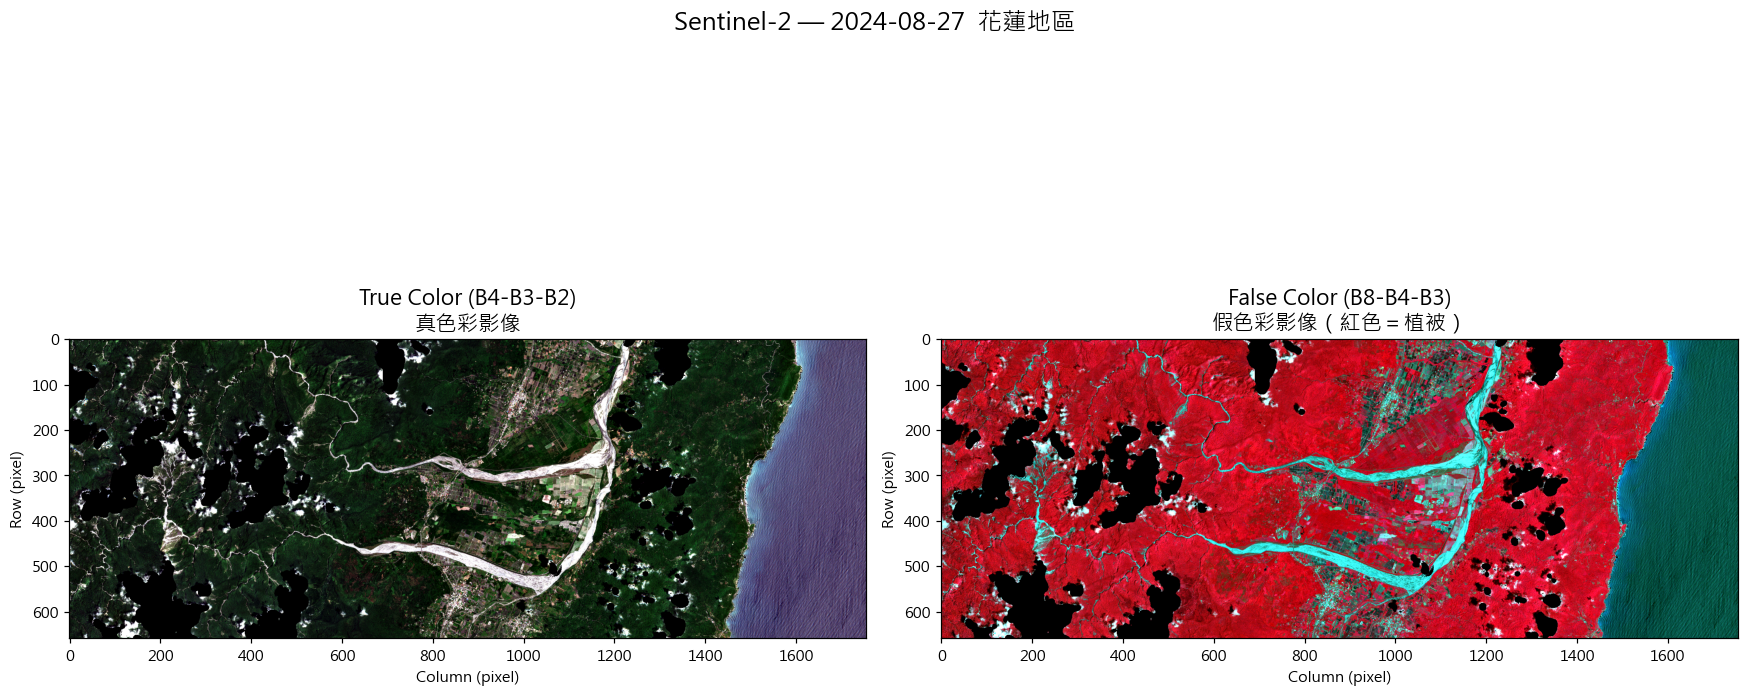

In [7]:
# =============================================================================
# [S4] RGB 真色彩 + 假色彩視覺化 【COMPLETE — 直接執行】
# =============================================================================


def percentile_stretch(band, low=2, high=98):
    """百分位拉伸：增強影像對比度"""
    valid = band[~np.isnan(band)]
    if len(valid) == 0:
        return band
    vmin = np.percentile(valid, low)
    vmax = np.percentile(valid, high)
    stretched = (band - vmin) / (vmax - vmin + 1e-10)
    return np.clip(stretched, 0, 1)


def make_rgb(img_array, band_indices, low=2, high=98):
    """組合 RGB 影像並做百分位拉伸"""
    rgb = np.stack(
        [percentile_stretch(img_array[i], low, high) for i in band_indices],
        axis=-1,
    )
    return np.nan_to_num(rgb, nan=0)


# 波段索引: B02=0(Blue), B03=1(Green), B04=2(Red),
#           B08=3(NIR),  B11=4(SWIR1), B12=5(SWIR2)
true_color = make_rgb(img, [2, 1, 0])    # R=B04, G=B03, B=B02
false_color = make_rgb(img, [3, 2, 1])   # R=B08, G=B04, B=B03

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(true_color)
axes[0].set_title("True Color (B4-B3-B2)\n真色彩影像", fontsize=14)
axes[0].set_xlabel("Column (pixel)")
axes[0].set_ylabel("Row (pixel)")

axes[1].imshow(false_color)
axes[1].set_title(
    "False Color (B8-B4-B3)\n假色彩影像（紅色＝植被）", fontsize=14
)
axes[1].set_xlabel("Column (pixel)")
axes[1].set_ylabel("Row (pixel)")

plt.suptitle(
    f"Sentinel-2 — {best_item.datetime.strftime('%Y-%m-%d')}  花蓮地區",
    fontsize=16,
    y=1.02,
)
plt.tight_layout()
plt.show()

## Lab 1: K-means 非監督分類

### 非監督式分類：讓演算法自動發現影像中的光譜群組

K-means 不需要訓練資料，直接根據像素的光譜特徵進行分群。
我們使用 6 個波段作為特徵空間，觀察不同 K 值的分類結果。

**步驟：**
1. 視覺化特徵空間（NIR vs Red 散佈圖）
2. 執行 K-means 分類
3. 分析各群組的光譜特徵
4. 比較不同 K 值的結果

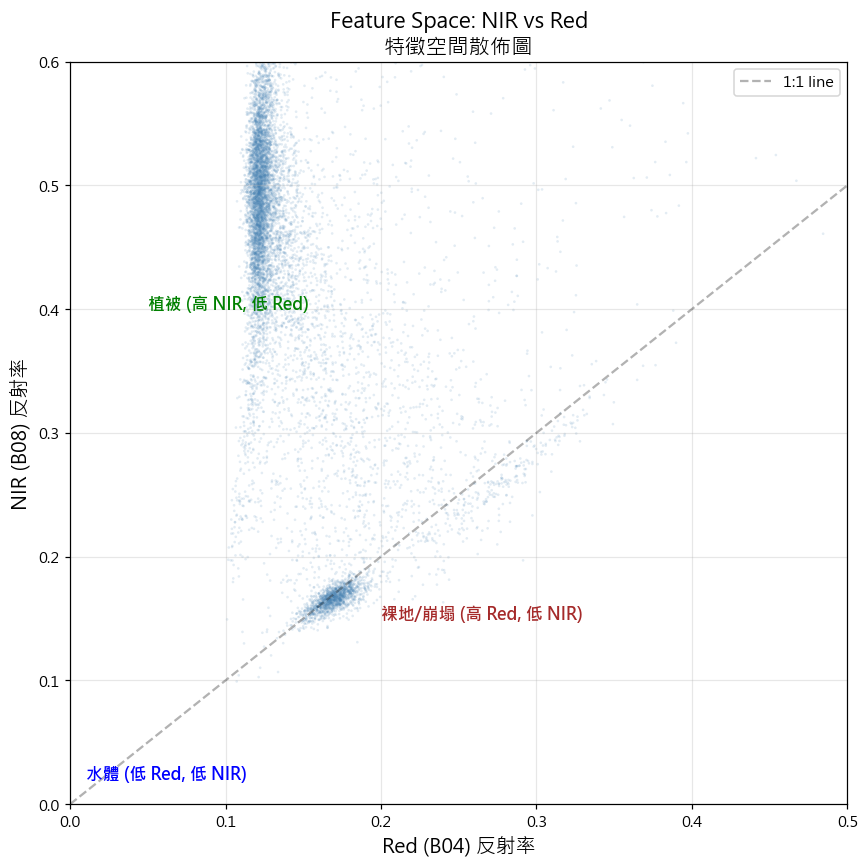

觀察：植被像素集中在左上方（高 NIR、低 Red），裸地/建物則靠近對角線。
這種分群結構就是 K-means 要找的 pattern。


In [8]:
# =============================================================================
# [S6] 特徵空間視覺化 — NIR vs Red 散佈圖 【YOUR TURN】
# =============================================================================

# 波段索引提示:
#   B02=0(Blue), B03=1(Green), B04=2(Red),
#   B08=3(NIR),  B11=4(SWIR1), B12=5(SWIR2)

# ── YOUR TURN ──
# 從 img 陣列中取出 NIR 和 Red 波段，展平為一維陣列
# Hint: NIR 是第 3 個波段 (index=3)，Red 是第 2 個波段 (index=2)
nir_flat = img[3].flatten()   # 替換 ___ 為正確的波段索引
red_flat = img[2].flatten()   # 替換 ___ 為正確的波段索引
# ── END YOUR TURN ──

# 移除 NaN（已預先填好）
valid_mask_2d = ~(np.isnan(nir_flat) | np.isnan(red_flat))
nir_valid = nir_flat[valid_mask_2d]
red_valid = red_flat[valid_mask_2d]

# 隨機抽樣 10000 個像素（避免繪圖過慢）
np.random.seed(42)
n_sample = min(10000, len(nir_valid))
sample_idx = np.random.choice(len(nir_valid), size=n_sample, replace=False)

# 繪製散佈圖
fig, ax = plt.subplots(figsize=(8, 8))

# ── YOUR TURN ──
# 使用 ax.scatter() 繪製散佈圖
# Hint: x 軸 = red_valid[sample_idx], y 軸 = nir_valid[sample_idx]
# Hint: 設定 c="steelblue", alpha=0.15, s=3, edgecolors="none"
ax.scatter(
    red_valid[sample_idx],   # x 軸：Red 反射率（抽樣後）
    nir_valid[sample_idx],   # y 軸：NIR 反射率（抽樣後）
    c="steelblue",
    alpha=0.15,
    s=3,
    edgecolors="none",
)
# ── END YOUR TURN ──

ax.set_xlabel("Red (B04) 反射率", fontsize=13)
ax.set_ylabel("NIR (B08) 反射率", fontsize=13)
ax.set_title("Feature Space: NIR vs Red\n特徵空間散佈圖", fontsize=14)
ax.set_xlim(0, 0.5)
ax.set_ylim(0, 0.6)

# 標註典型區域
ax.annotate(
    "植被 (高 NIR, 低 Red)",
    xy=(0.05, 0.4),
    fontsize=11,
    color="green",
    fontweight="bold",
)
ax.annotate(
    "裸地/崩塌 (高 Red, 低 NIR)",
    xy=(0.2, 0.15),
    fontsize=11,
    color="brown",
    fontweight="bold",
)
ax.annotate(
    "水體 (低 Red, 低 NIR)",
    xy=(0.01, 0.02),
    fontsize=11,
    color="blue",
    fontweight="bold",
)

# 對角線（soil line 參考）
ax.plot([0, 0.5], [0, 0.5], "k--", alpha=0.3, label="1:1 line")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("觀察：植被像素集中在左上方（高 NIR、低 Red），裸地/建物則靠近對角線。")
print("這種分群結構就是 K-means 要找的 pattern。")

總像素數    : 1,156,545
有效像素數  : 1,042,083
特徵維度    : 6 波段

正在執行 K-means (K=5)...
K-means 完成！ Inertia = 4881.91


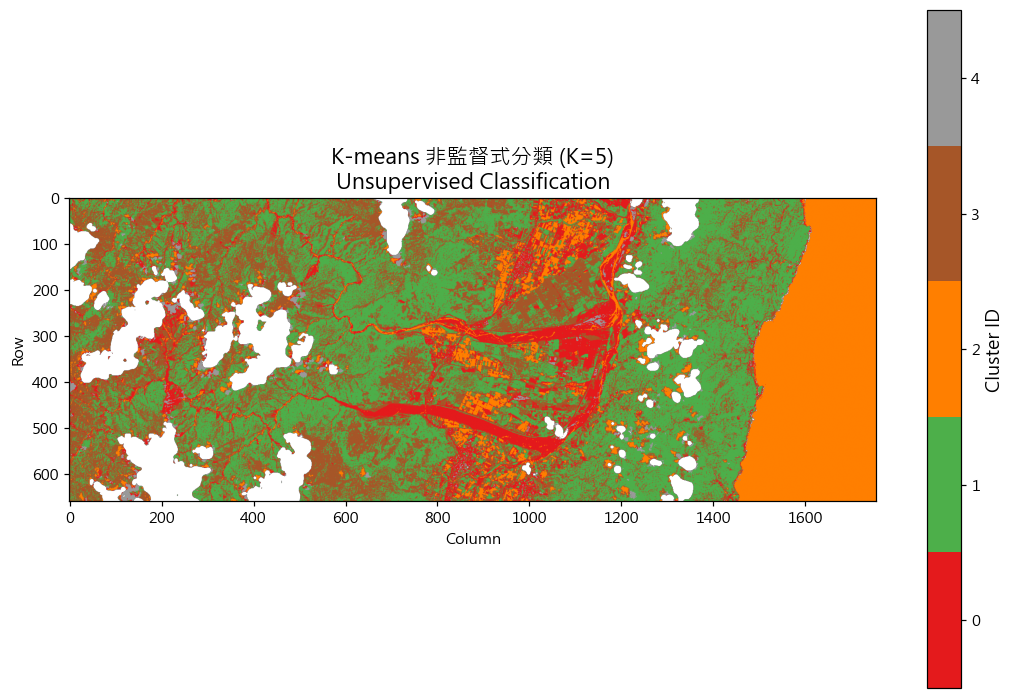


各群組像素統計:
  Cluster 0:   93,717 pixels (9.0%)
  Cluster 1:  408,212 pixels (39.2%)
  Cluster 2:  197,376 pixels (18.9%)
  Cluster 3:  327,726 pixels (31.4%)
  Cluster 4:   15,052 pixels (1.4%)


In [9]:
# =============================================================================
# [S7] K-means 分類 (K=5) 【YOUR TURN】
# =============================================================================

# --- 建立特徵矩陣（已預先填好）---
# 重塑為 (n_pixels, n_bands)
pixels = img.reshape(n_bands, -1).T  # shape: (n_pixels, 6)

# 找出有效像素（所有波段皆非 NaN）
valid_pixel_mask = ~np.any(np.isnan(pixels), axis=1)
pixels_valid = pixels[valid_pixel_mask]

print(f"總像素數    : {pixels.shape[0]:,}")
print(f"有效像素數  : {pixels_valid.shape[0]:,}")
print(f"特徵維度    : {pixels_valid.shape[1]} 波段")

# ── YOUR TURN ──
# 1. 建立 KMeans 模型並進行分類
# Hint: KMeans(n_clusters=5, random_state=42, n_init=10, max_iter=300)
K = 5
print(f"\n正在執行 K-means (K={K})...")

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10, max_iter=300)  # 建立 KMeans 物件
labels_km = kmeans.fit_predict(pixels_valid)  # 使用 fit_predict() 對 pixels_valid 進行分類

print(f"K-means 完成！ Inertia = {kmeans.inertia_:.2f}")
# ── END YOUR TURN ──

# --- 重建分類圖（已預先填好）---
class_map_km = np.full(pixels.shape[0], np.nan)
class_map_km[valid_pixel_mask] = labels_km
class_map_km = class_map_km.reshape(n_rows, n_cols)

# ── YOUR TURN ──
# 2. 視覺化分類結果
# Hint: 使用 ax.imshow() 顯示 class_map_km
# Hint: 使用 plt.cm.get_cmap("Set1", K) 作為色彩映射
fig, ax = plt.subplots(figsize=(10, 8))
cmap_km = plt.cm.get_cmap("Set1", K)

im = ax.imshow(class_map_km, cmap=cmap_km, vmin=-0.5, vmax=K - 0.5)  # 填入正確的資料和色彩映射

cbar = plt.colorbar(im, ax=ax, ticks=range(K), shrink=0.8)
cbar.set_label("Cluster ID", fontsize=12)
ax.set_title(
    f"K-means 非監督式分類 (K={K})\nUnsupervised Classification", fontsize=14
)
ax.set_xlabel("Column")
ax.set_ylabel("Row")
plt.tight_layout()
plt.show()
# ── END YOUR TURN ──

# 統計各群組像素數
print("\n各群組像素統計:")
for c in range(K):
    count = np.sum(labels_km == c)
    print(f"  Cluster {c}: {count:>8,} pixels ({count / len(labels_km) * 100:.1f}%)")

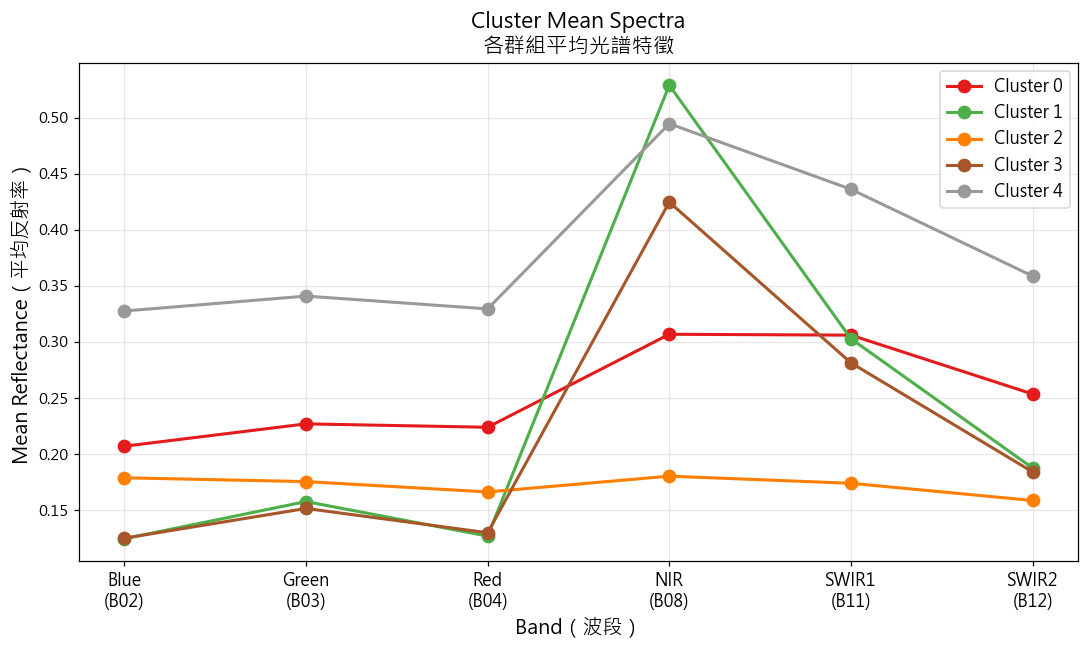


=== 光譜特徵判讀指引（檢查你的結果是否合理）===
  - NIR 高、Red 低 → 健康植被
  - 所有波段都低   → 水體
  - Red/SWIR 高    → 裸地 / 崩塌地
  - 整體偏亮       → 建物 / 人造地物

提示：如果你的圖中有一條曲線在 NIR 處有明顯高峰，那很可能是植被 cluster。


In [10]:
# =============================================================================
# [S8] 各群組光譜特徵分析 【YOUR TURN】
# =============================================================================

# 繪圖設定（已預先填好）
fig, ax = plt.subplots(figsize=(10, 6))
colors_spec = plt.cm.Set1(np.linspace(0, 1, K))

# ── YOUR TURN ──
# 計算每個 cluster 的平均反射率，並繪製光譜曲線
# Hint: 對每個 cluster c (0 到 K-1)：
#   1. 用 pixels_valid[labels_km == c] 取出該 cluster 的像素
#   2. 用 .mean(axis=0) 計算平均光譜
#   3. 用 ax.plot() 繪製折線圖

cluster_means = np.zeros((K, n_bands))

for c in range(K):
    # 計算第 c 個 cluster 的平均反射率
    cluster_means[c] = pixels_valid[labels_km == c].mean(axis=0)  # Hint: pixels_valid[labels_km == c].mean(axis=0)

    # 繪製該 cluster 的光譜曲線
    ax.plot(
        range(n_bands),
        cluster_means[c],  # Hint: cluster_means[c]
        "o-",
        color=colors_spec[c],
        linewidth=2,
        markersize=8,
        label=f"Cluster {c}",
    )
# ── END YOUR TURN ──

ax.set_xticks(range(n_bands))
ax.set_xticklabels(
    [f"{BAND_NAMES[i]}\n({BANDS[i]})" for i in range(n_bands)], fontsize=11
)
ax.set_ylabel("Mean Reflectance（平均反射率）", fontsize=13)
ax.set_xlabel("Band（波段）", fontsize=13)
ax.set_title("Cluster Mean Spectra\n各群組平均光譜特徵", fontsize=14)
ax.legend(fontsize=11, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 答案驗驗證：預期光譜模式
print("\n=== 光譜特徵判讀指引（檢查你的結果是否合理）===")
print("  - NIR 高、Red 低 → 健康植被")
print("  - 所有波段都低   → 水體")
print("  - Red/SWIR 高    → 裸地 / 崩塌地")
print("  - 整體偏亮       → 建物 / 人造地物")
print("\n提示：如果你的圖中有一條曲線在 NIR 處有明顯高峰，那很可能是植被 cluster。")

### 課堂練習：你的 cluster 是什麼地物？

根據上方的光譜分析結果，請嘗試將每個 cluster 對應到可能的土地覆蓋類型。

| Cluster | 你觀察到的光譜特徵 | 推測的地物類型 |
|---------|-------------------|---------------|
| 0 | Red/SWIR 高 | 裸地 |
| 1 | NIR 高、Red 低 | 植被 |
| 2 | 所有波段都低 | 水體 |
| 3 | NIR 次高、Red 低 | 混合植被(農田) |
| 4 | 整體偏亮 | 看不出來(理論上是建物 / 人造地物) |

**思考題：**

1. 非監督分類的 cluster 編號沒有固定意義，每次執行結果可能不同。你能確定每個 cluster 一定只對應一種地物嗎？為什麼？

- A:不能，看河道與裸地混淆便知，一個 cluster 經常包含多種不同物理意義的地物，而同一種地物也可能被拆分到不同的 cluster 中。

原因：K-means 演算法是「盲目」的數學運算。它只在乎像素在多維特徵空間（如 B2, B3, B4, B8 等波段數值）中的「歐式距離」是否靠近。

現象：如果兩種完全不同的地物（例如：深色的老舊柏油路與清澈的淺水潭）剛好具有極為相似的反射率數值，K-means 就會把它們分進同一個 cluster。反過來說，同樣是森林，向陽面的樹冠（反射率高）與背陰面的樹冠（反射率低）可能因為數值差異夠大，而被 K-means 拆分成兩個不同的 cluster。

2. 觀察分類圖：陸地上是否有和海洋相同顏色的像素？如果有，你認為那些像素實際上是什麼？（提示：想想雲影和地形陰影的光譜特徵）

- A:依照街景，西方與水體同色的像素為套黑色塑膠膜的農地，造成大量反射而判成水體。東方則為海岸山脈陰影。

3. K-means 為什麼會把陰影和水體分到同一類？這暗示了非監督分類的什麼限制？
- A:光譜數值的高度重疊（低反射率）。
水體的物理特性是強烈吸收近紅外光與中紅外光，導致其在這些波段的數值極低；而陰影區則是因為陽光被雲層或山脈阻擋，感測器接收到的反射輻射量同樣極低。在 K-means 的特徵空間座標中，這兩者都集中在靠近原點（低數值區）的位置，距離極為接近，因此被判定為同一群。顯示其有光譜混淆與缺乏空間脈絡的限制，河道部分需比較不同時間資料，其他可用監督式學習去改。

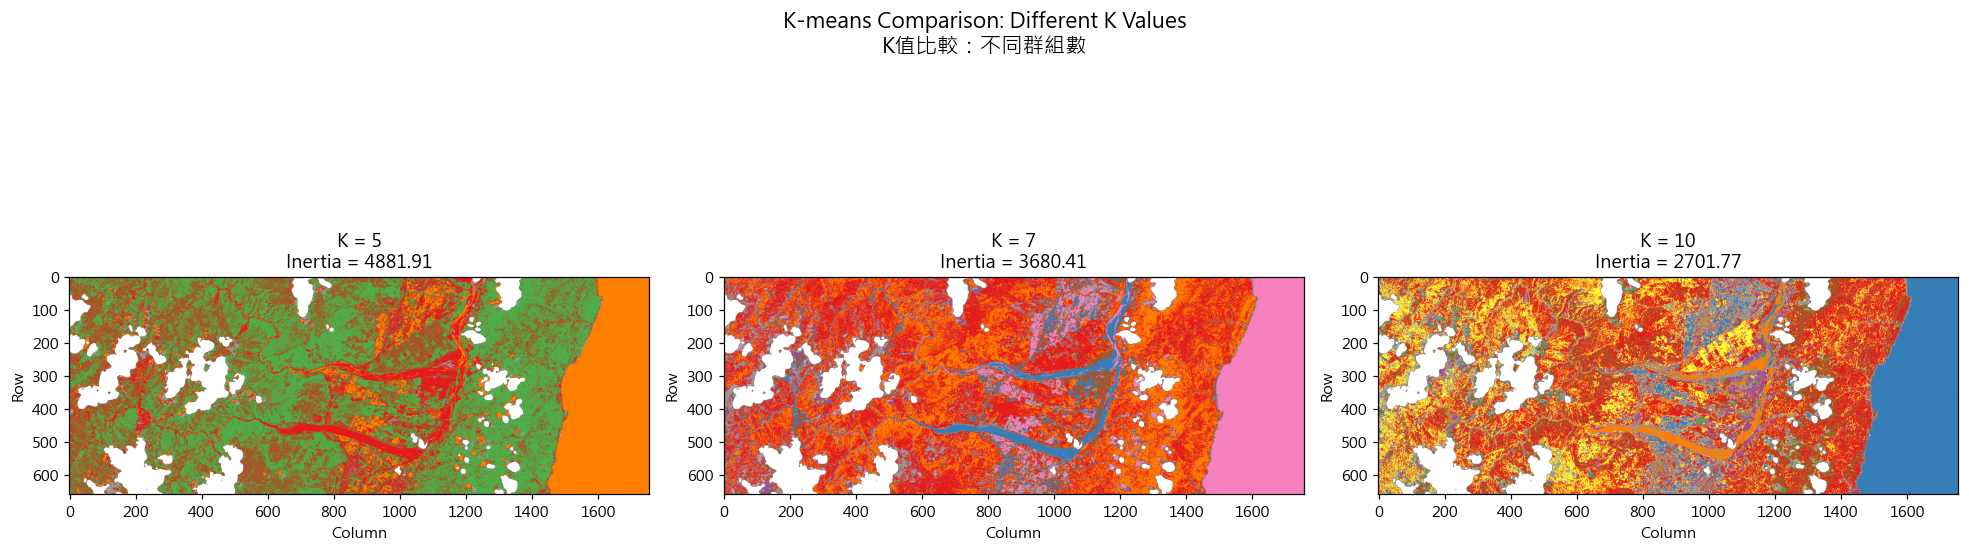

觀察：K 值越大，Inertia 越小（分群更細），但可能過度分割。
K=5 通常適合一般土地覆蓋分類，K=10 可能過於細碎。


In [11]:
# =============================================================================
# [S10] K 值比較：K=5, 7, 10 【YOUR TURN】
# =============================================================================

# 測試不同的 K 值，觀察分群效果變化
K_values = [5, 7, 10]
fig, axes = plt.subplots(1, len(K_values), figsize=(18, 6))

for idx, K in enumerate(K_values):
    # ── YOUR TURN ──
    # 執行 K-means 分類
    # Hint: KMeans(n_clusters=K, random_state=42, n_init=10, max_iter=300)
    km_temp = KMeans(n_clusters=K, random_state=42, n_init=10, max_iter=300)  # 建立 KMeans 物件
    lbl = km_temp.fit_predict(pixels_valid)  # 使用 fit_predict() 進行分類
    # ── END YOUR TURN ──
    
    # 重建分類圖
    class_map_temp = np.full(pixels.shape[0], np.nan)
    class_map_temp[valid_pixel_mask] = lbl
    class_map_temp = class_map_temp.reshape(n_rows, n_cols)
    
    # 視覺化
    cmap_temp = plt.cm.get_cmap("Set1", K)
    axes[idx].imshow(class_map_temp, cmap=cmap_temp, vmin=-0.5, vmax=K-0.5)
    axes[idx].set_title(f"K = {K}\nInertia = {km_temp.inertia_:.2f}", fontsize=12)
    axes[idx].set_xlabel("Column")
    axes[idx].set_ylabel("Row")

plt.suptitle("K-means Comparison: Different K Values\nK值比較：不同群組數", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("觀察：K 值越大，Inertia 越小（分群更細），但可能過度分割。")
print("K=5 通常適合一般土地覆蓋分類，K=10 可能過於細碎。")

## Lab 2: Random Forest 監督分類

### 監督式分類：使用訓練樣本建立 Random Forest 分類模型

需要事先定義各類別的訓練區域（ROI），再讓模型學習光譜特徵與類別的對應關係。

**你的任務：** 在 Google Earth 上繪製 5 類地物的多邊形 ROI，匯出為 KMZ，上傳到 Colab。

| Class | 名稱 | 說明 | 選取建議 |
|-------|------|------|---------|
| 0 | 水體 | 海洋、河流 | 花蓮外海明顯的深藍色區域 |
| 1 | 森林 | 山坡密林 | 中央山脈東側，深綠色區域 |
| 2 | 農地 | 水稻田等 | 花蓮縱谷，淺綠色規則區塊 |
| 3 | 裸地/崩塌 | 河床、崩塌面 | 花蓮溪河床、山區裸露面 |
| 4 | 建物 | 市區建築 | 花蓮市中心，灰白色區域 |

**KMZ 製作步驟：**
1. 開啟 Google Earth Pro
2. 對每一類地物，使用「新增多邊形」工具框選代表性區域
3. **多邊形命名必須是：** `水體`、`森林`、`農地`、`裸露地`、`建物`（中文名稱）
4. 每類建議畫 2–3 個多邊形，越大越好（至少 50 個像素 ≈ 200m × 200m）
5. 全選 → 右鍵 → 「將地點另存為...」→ 存成 `.kmz`

**步驟：**
1. 上傳 KMZ → 自動解析 ROI
2. 訓練 Random Forest 模型
3. 對全影像進行分類預測
4. 評估分類精度（混淆矩陣、OA、Kappa）
5. 後處理（中值濾波）

使用 KMZ 檔案: aria_training_data.kmz

--- 解析 KMZ ---
  ✓ 森林 → Forest
  ✓ 森林 → Forest
  ✓ 森林 → Forest
  ✓ 水體 → Water
  ✓ 水體 → Water
  ✓ 農地 → Agriculture
  ✓ 農地 → Agriculture
  ✓ 農地 → Agriculture
  ✓ 建物 → Built-up
  ✓ 建物 → Built-up
  ✓ 裸露地 → Bare/Landslide
  ✓ 裸露地 → Bare/Landslide

=== 訓練樣本統計 ===
總訓練像素數: 109,211

  Class 0 (           Water / 水體): 39,403 pixels, 2 個多邊形  ✅
  Class 1 (          Forest / 森林): 59,370 pixels, 3 個多邊形  ✅
  Class 2 (     Agriculture / 農地):  3,325 pixels, 3 個多邊形  ✅
  Class 3 (  Bare/Landslide / 裸地/崩塌):  6,764 pixels, 2 個多邊形  ✅
  Class 4 (        Built-up / 建物):    349 pixels, 2 個多邊形  ✅


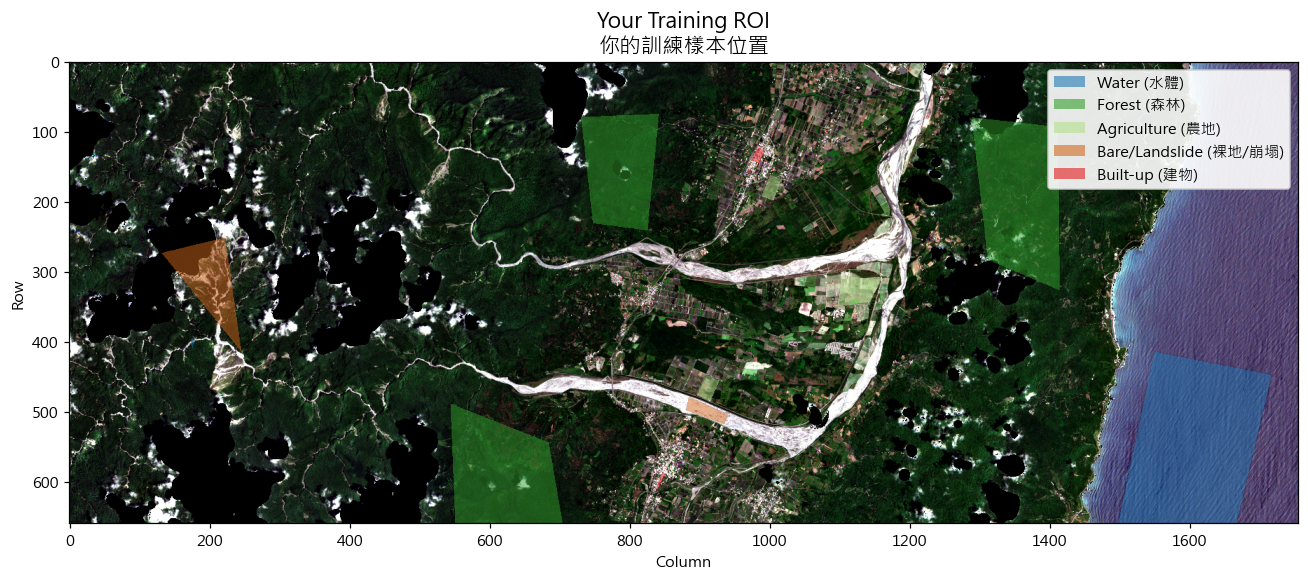


檢查你的 ROI 是否合理：
  - 水體 ROI 是否確實在海面或河流上？
  - 森林 ROI 是否在山坡密林區？
  - 每類是否至少有 30+ 像素？


In [13]:
# =============================================================================
# [S12] 上傳 KMZ + 解析 ROI 訓練樣本 【YOUR TURN — 上傳你的 KMZ】
# =============================================================================
# 步驟：
#   1. 在 Google Earth Pro 繪製多邊形 ROI（見上方說明）
#   2. 匯出為 KMZ 檔案
#   3. 程式自動解析多邊形 → 轉 UTM → 柵格化 → 提取訓練像素

import zipfile
import xml.etree.ElementTree as ET
from shapely.geometry import Polygon
import pyproj
from rasterio.features import rasterize
import matplotlib.patches as mpatches

# --- 類別定義 ---
CLASS_NAMES = ["Water", "Forest", "Agriculture", "Bare/Landslide", "Built-up"]
CLASS_NAMES_ZH = ["水體", "森林", "農地", "裸地/崩塌", "建物"]
N_CLASSES = len(CLASS_NAMES)

# KMZ 中的多邊形名稱 → 類別 ID 對照表
# （你在 Google Earth 裡的多邊形名稱必須包含以下關鍵字之一）
name_to_class = {
    "水體": 0, "水": 0, "Water": 0, "water": 0,
    "森林": 1, "林": 1, "Forest": 1, "forest": 1,
    "農地": 2, "農": 2, "Agriculture": 2, "agriculture": 2, "Cropland": 2,
    "裸露地": 3, "裸地": 3, "崩塌": 3, "裸": 3, "Bare": 3, "bare": 3, "Landslide": 3,
    "建物": 4, "建": 4, "Built": 4, "built": 4, "Built-up": 4,
}

# ── YOUR TURN ──
# 指定你的 KMZ 檔案路徑
kmz_filename = "aria_training_data.kmz"  # 替換為你的 KMZ 檔案名稱
print(f"使用 KMZ 檔案: {kmz_filename}")
# ── END YOUR TURN ──

# --- 解析 KMZ（自動處理，不需修改）---
def parse_kmz(filename):
    """解析 KMZ 檔案，回傳 {class_id: [Polygon, ...]} 字典"""
    ns = {"kml": "http://www.opengis.net/kml/2.2"}
    polygons_by_class = {i: [] for i in range(N_CLASSES)}

    with zipfile.ZipFile(filename, 'r') as z:
        kml_name = [n for n in z.namelist() if n.endswith('.kml')][0]
        with z.open(kml_name) as f:
            tree = ET.parse(f)

    for pm in tree.findall(".//{http://www.opengis.net/kml/2.2}Placemark"):
        name_elem = pm.find("{http://www.opengis.net/kml/2.2}name")
        coords_elem = pm.find(".//{http://www.opengis.net/kml/2.2}coordinates")
        if name_elem is None or coords_elem is None:
            continue

        # 比對名稱 → 類別 ID
        pm_name = name_elem.text.strip()
        cls_id = None
        for keyword, cid in name_to_class.items():
            if keyword in pm_name:
                cls_id = cid
                break
        if cls_id is None:
            print(f"  ⚠️ 無法辨識類別: '{pm_name}'，已跳過")
            continue

        # 解析座標
        coords_text = coords_elem.text.strip()
        points = []
        for c in coords_text.split():
            parts = c.split(",")
            points.append((float(parts[0]), float(parts[1])))

        if len(points) >= 3:
            poly = Polygon(points)
            if poly.is_valid and poly.area > 0:
                polygons_by_class[cls_id].append(poly)
                print(f"  ✓ {pm_name} → {CLASS_NAMES[cls_id]}")

    return polygons_by_class

print("\n--- 解析 KMZ ---")
polygons_by_class = parse_kmz(kmz_filename)

# --- 轉 UTM + 柵格化（自動處理）---
transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:32651", always_xy=True)
shapes_for_rasterize = []

for cls_id, poly_list in polygons_by_class.items():
    for poly in poly_list:
        coords_utm = [transformer.transform(x, y) for x, y in poly.exterior.coords]
        poly_utm = Polygon(coords_utm)
        if poly_utm.is_valid and poly_utm.area > 0:
            shapes_for_rasterize.append((poly_utm, cls_id))

roi_raster = rasterize(
    shapes_for_rasterize,
    out_shape=(n_rows, n_cols),
    transform=img_transform,
    fill=-1,
    dtype=np.int8,
    all_touched=True,
)

# --- 提取訓練像素 ---
X_train_list = []
y_train_list = []

for cls_id in range(N_CLASSES):
    cls_mask = (roi_raster == cls_id)
    cls_pixels = img[:, cls_mask].T
    valid_rows = ~np.any(np.isnan(cls_pixels), axis=1)
    cls_valid = cls_pixels[valid_rows]
    if len(cls_valid) > 0:
        X_train_list.append(cls_valid)
        y_train_list.append(np.full(len(cls_valid), cls_id))

X_roi = np.vstack(X_train_list)
y_roi = np.concatenate(y_train_list)

# --- 統計報告 ---
print("\n=== 訓練樣本統計 ===")
print(f"總訓練像素數: {len(y_roi):,}\n")
for cls_id in range(N_CLASSES):
    count = int(np.sum(y_roi == cls_id))
    n_poly = len(polygons_by_class[cls_id])
    status = "✅" if count >= 30 else "⚠️ 偏少，建議增加 ROI"
    print(
        f"  Class {cls_id} ({CLASS_NAMES[cls_id]:>16s} / "
        f"{CLASS_NAMES_ZH[cls_id]}): {count:>6,} pixels, "
        f"{n_poly} 個多邊形  {status}"
    )

# --- 視覺化 ROI ---
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(make_rgb(img, [2, 1, 0]))

roi_colors_vis = ["#1f78b4", "#33a02c", "#b2df8a", "#d2691e", "#e31a1c"]
for cls_id in range(N_CLASSES):
    mask = (roi_raster == cls_id)
    if np.any(mask):
        overlay = np.zeros((*mask.shape, 4))
        c = mcolors.to_rgba(roi_colors_vis[cls_id], alpha=0.5)
        overlay[mask] = c
        ax.imshow(overlay)

legend_roi = [Patch(facecolor=roi_colors_vis[i], alpha=0.6,
                    label=f"{CLASS_NAMES[i]} ({CLASS_NAMES_ZH[i]})")
              for i in range(N_CLASSES)]
ax.legend(handles=legend_roi, loc="upper right", fontsize=10, framealpha=0.9)
ax.set_title("Your Training ROI\n你的訓練樣本位置", fontsize=14)
ax.set_xlabel("Column")
ax.set_ylabel("Row")
plt.tight_layout()
plt.show()

print("\n檢查你的 ROI 是否合理：")
print("  - 水體 ROI 是否確實在海面或河流上？")
print("  - 森林 ROI 是否在山坡密林區？")
print("  - 每類是否至少有 30+ 像素？")

In [14]:
# =============================================================================
# [S13] 訓練 Random Forest 模型 【YOUR TURN】
# =============================================================================

# 80/20 分割，保持類別比例（已預先填好）
X_tr, X_te, y_tr, y_te = train_test_split(
    X_roi, y_roi, test_size=0.2, random_state=42, stratify=y_roi
)

print(f"訓練集: {len(y_tr):,} 像素")
print(f"測試集: {len(y_te):,} 像素")

# ── YOUR TURN ──
# 1. 建立 Random Forest 分類器
# Hint: RandomForestClassifier(n_estimators=200, max_features="sqrt",
#                              random_state=42, n_jobs=-1, oob_score=True)

rf = RandomForestClassifier(n_estimators=200, max_features="sqrt",
                           random_state=42, n_jobs=-1, oob_score=True)  # 建立 RandomForestClassifier 物件

# 2. 訓練模型
# Hint: 使用 rf.fit(X_tr, y_tr)
print("\n正在訓練 Random Forest（n_estimators=200）...")
rf.fit(X_tr, y_tr)  # 訓練模型

# 3. 預測測試集並計算精度
# Hint: rf.predict(X_te) 和 accuracy_score(y_te, y_pred_test)
y_pred_test = rf.predict(X_te)    # 對測試集進行預測
test_acc = accuracy_score(y_te, y_pred_test)       # 計算測試集精度
oob_acc = rf.oob_score_  # OOB 精度（Random Forest 內建）

print(f"\n=== 模型評估 ===")
print(f"  Test Accuracy : {test_acc:.4f} ({test_acc * 100:.2f}%)")
print(f"  OOB  Accuracy : {oob_acc:.4f} ({oob_acc * 100:.2f}%)")
# ── END YOUR TURN ──

print("\n=== Classification Report ===")
print(classification_report(y_te, y_pred_test, target_names=CLASS_NAMES, digits=4))

訓練集: 87,368 像素
測試集: 21,843 像素

正在訓練 Random Forest（n_estimators=200）...

=== 模型評估 ===
  Test Accuracy : 0.9632 (96.32%)
  OOB  Accuracy : 0.9619 (96.19%)

=== Classification Report ===
                precision    recall  f1-score   support

         Water     0.9995    0.9990    0.9992      7881
        Forest     0.9549    0.9903    0.9723     11874
   Agriculture     0.9228    0.8271    0.8723       665
Bare/Landslide     0.8121    0.6038    0.6927      1353
      Built-up     0.8367    0.5857    0.6891        70

      accuracy                         0.9632     21843
     macro avg     0.9052    0.8012    0.8451     21843
  weighted avg     0.9608    0.9632    0.9607     21843



正在對全影像進行分類預測...


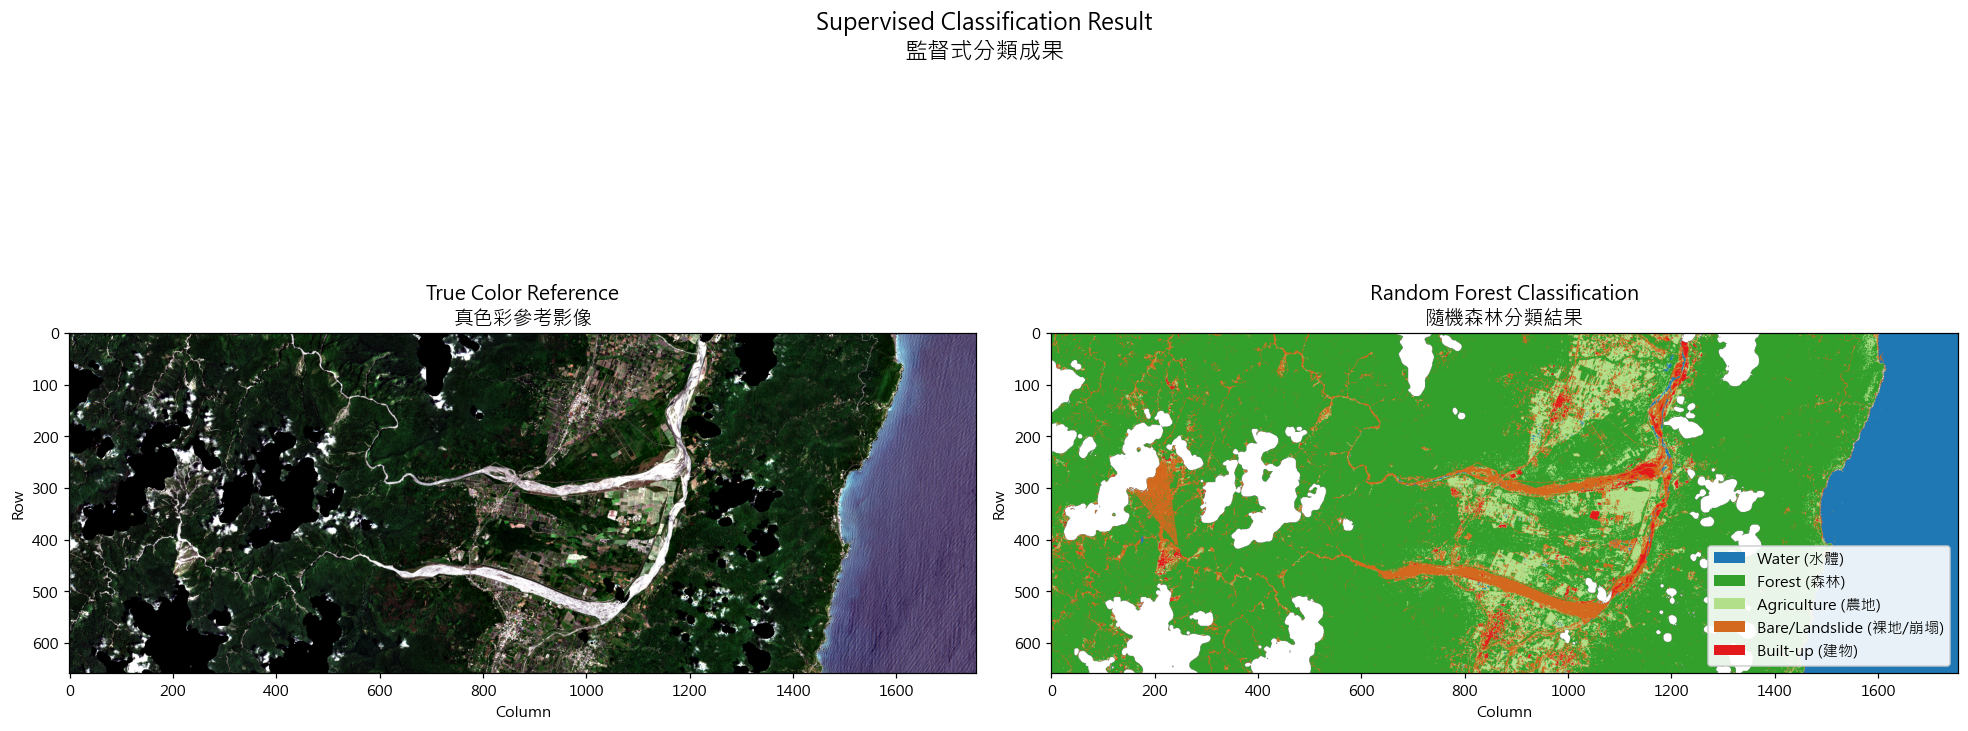

分類完成。


In [15]:
# =============================================================================
# [S14] 全影像分類 + 分類圖視覺化 【YOUR TURN】
# =============================================================================

# --- 分類配色設定（已預先填好）---
lc_colors = [
    "#1f78b4",  # 0: Water — 藍色
    "#33a02c",  # 1: Forest — 深綠
    "#b2df8a",  # 2: Agriculture — 淺綠
    "#d2691e",  # 3: Bare/Landslide — 棕色
    "#e31a1c",  # 4: Built-up — 紅色
]
lc_cmap = mcolors.ListedColormap(lc_colors)
lc_bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
lc_norm = mcolors.BoundaryNorm(lc_bounds, lc_cmap.N)

# ── YOUR TURN ──
# 1. 對所有有效像素進行分類預測
# Hint: 使用 rf.predict(pixels_valid)
print("正在對全影像進行分類預測...")
rf_labels = rf.predict(pixels_valid)  # 對 pixels_valid 進行預測

# 2. 重建分類圖（將一維結果還原為二維影像）
# Hint: 先建立全 NaN 陣列，再填入預測結果，最後 reshape
class_map_rf = np.full(pixels.shape[0], np.nan)
class_map_rf[valid_pixel_mask] = rf_labels  # 填入預測結果
class_map_rf = class_map_rf.reshape(n_rows, n_cols)  # 填入正確的行列數
# ── END YOUR TURN ──

# --- 視覺化（已預先填好）---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 左：真色彩
axes[0].imshow(true_color)
axes[0].set_title("True Color Reference\n真色彩參考影像", fontsize=13)

# 右：分類結果
im = axes[1].imshow(class_map_rf, cmap=lc_cmap, norm=lc_norm)
axes[1].set_title("Random Forest Classification\n隨機森林分類結果", fontsize=13)

# 圖例
legend_patches = [
    Patch(facecolor=lc_colors[i], label=f"{CLASS_NAMES[i]} ({CLASS_NAMES_ZH[i]})")
    for i in range(N_CLASSES)
]
axes[1].legend(
    handles=legend_patches,
    loc="lower right",
    fontsize=10,
    framealpha=0.9,
    fancybox=True,
)

for ax in axes:
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")

plt.suptitle(
    "Supervised Classification Result\n監督式分類成果", fontsize=15, y=1.02
)
plt.tight_layout()
plt.show()
print("分類完成。")

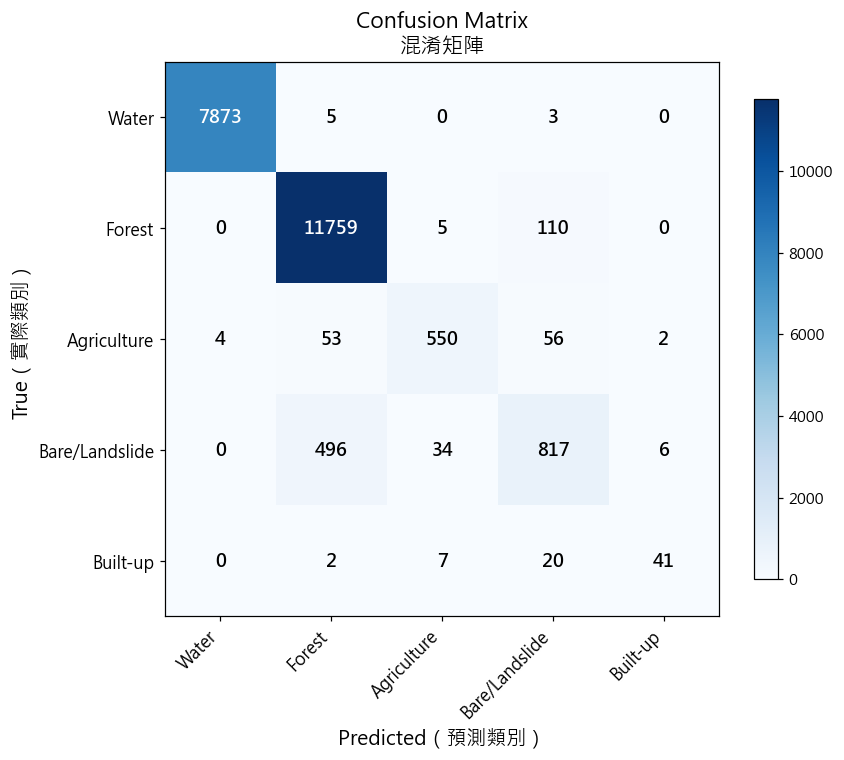


Overall Accuracy (OA) : 0.9632 (96.32%)
Cohen's Kappa         : 0.9343

判讀：Kappa > 0.8 為 almost perfect agreement


In [16]:
# =============================================================================
# [S15] 混淆矩陣 + OA / Kappa 【YOUR TURN】
# =============================================================================

# 計算混淆矩陣（已預先填好）
cm = confusion_matrix(y_te, y_pred_test)

# ── YOUR TURN ──
# 1. 繪製混淆矩陣熱力圖
# Hint: 使用 ax.imshow(cm, cmap="Blues") 顯示混淆矩陣
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")  # 填入混淆矩陣
plt.colorbar(im, ax=ax, shrink=0.8)

# 在格子中標註數值
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
            fontsize=12, fontweight="bold", color=color,
        )

ax.set_xticks(range(N_CLASSES))
ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(CLASS_NAMES, fontsize=11)
ax.set_xlabel("Predicted（預測類別）", fontsize=13)
ax.set_ylabel("True（實際類別）", fontsize=13)
ax.set_title("Confusion Matrix\n混淆矩陣", fontsize=14)
plt.tight_layout()
plt.show()
# ── END YOUR TURN ──

# ── YOUR TURN ──
# 2. 計算 Overall Accuracy (OA) 和 Cohen's Kappa
# Hint: accuracy_score(y_te, y_pred_test) 和 cohen_kappa_score(y_te, y_pred_test)
OA = accuracy_score(y_te, y_pred_test)     # 計算 Overall Accuracy
kappa = cohen_kappa_score(y_te, y_pred_test)  # 計算 Cohen's Kappa

print(f"\nOverall Accuracy (OA) : {OA:.4f} ({OA * 100:.2f}%)")
print(f"Cohen's Kappa         : {kappa:.4f}")
print(f"\n判讀：Kappa > 0.8 為 almost perfect agreement")
# ── END YOUR TURN ──

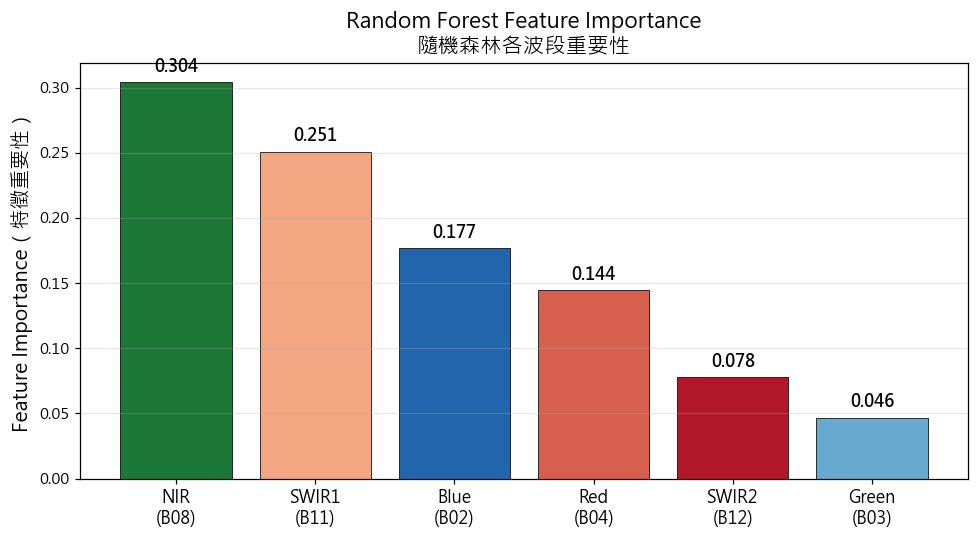


=== 特徵重要性排序 ===
  1. NIR    (B08): 0.3040
  2. SWIR1  (B11): 0.2509
  3. Blue   (B02): 0.1766
  4. Red    (B04): 0.1444
  5. SWIR2  (B12): 0.0777
  6. Green  (B03): 0.0464

分析：NIR 和 SWIR 波段通常對土地覆蓋分類最重要，
因為它們能有效區分植被、水體和裸露地表。


In [17]:
# =============================================================================
# [S16] 特徵重要性分析 【COMPLETE — 直接執行】
# =============================================================================

importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ["#2166ac", "#67a9cf", "#d6604d", "#1b7837", "#f4a582", "#b2182b"]

bars = ax.bar(
    range(n_bands),
    importances[sorted_idx],
    color=[bar_colors[i] for i in sorted_idx],
    edgecolor="black",
    linewidth=0.5,
)

ax.set_xticks(range(n_bands))
ax.set_xticklabels(
    [f"{BAND_NAMES[i]}\n({BANDS[i]})" for i in sorted_idx], fontsize=11
)
ax.set_ylabel("Feature Importance（特徵重要性）", fontsize=13)
ax.set_title("Random Forest Feature Importance\n隨機森林各波段重要性", fontsize=14)
ax.grid(axis="y", alpha=0.3)

# 在柱狀圖上標數值
for bar_obj, imp in zip(bars, importances[sorted_idx]):
    ax.text(
        bar_obj.get_x() + bar_obj.get_width() / 2,
        bar_obj.get_height() + 0.005,
        f"{imp:.3f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )

plt.tight_layout()
plt.show()

print("\n=== 特徵重要性排序 ===")
for rank, idx in enumerate(sorted_idx):
    print(f"  {rank + 1}. {BAND_NAMES[idx]:6s} ({BANDS[idx]}): {importances[idx]:.4f}")

print("\n分析：NIR 和 SWIR 波段通常對土地覆蓋分類最重要，")
print("因為它們能有效區分植被、水體和裸露地表。")

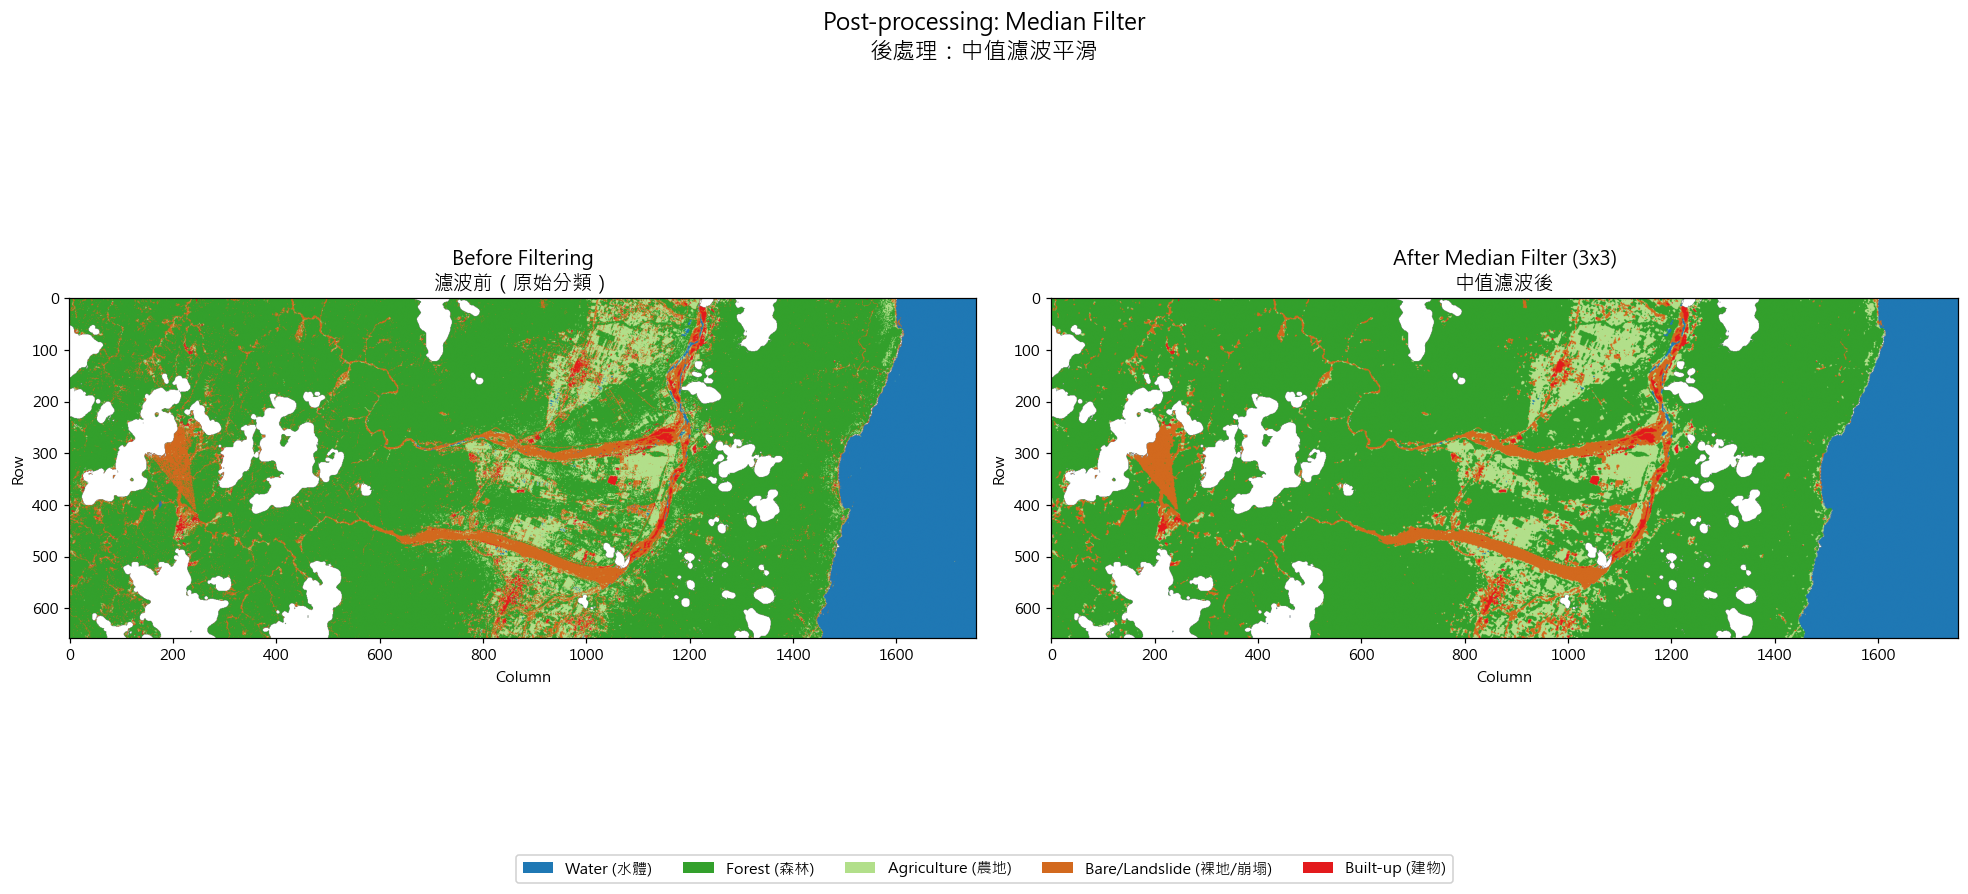

變更像素數: 72,296 / 1,042,083 (6.94%)
中值濾波可消除零碎的 salt-and-pepper 雜訊，使分類結果更平滑。


In [18]:
# =============================================================================
# [S17] 後處理 — 中值濾波 【YOUR TURN】
# =============================================================================

# ── YOUR TURN ──
# 1. 將分類圖中的 NaN 暫時填充為 -1，轉為整數
# Hint: np.nan_to_num(class_map_rf, nan=-1).astype(np.int8)
map_for_filter = np.nan_to_num(class_map_rf, nan=-1).astype(np.int8)

# 2. 套用 3x3 中值濾波
# Hint: median_filter(map_for_filter, size=3)
map_filtered = median_filter(map_for_filter, size=3)

# 3. 恢復 NaN
class_map_filtered = map_filtered.astype(float)
class_map_filtered[map_for_filter == -1] = np.nan
# ── END YOUR TURN ──

# 計算變更像素數（已預先填好）
valid_comparison = (~np.isnan(class_map_rf)) & (~np.isnan(class_map_filtered))
pixels_changed = int(
    np.sum(class_map_rf[valid_comparison] != class_map_filtered[valid_comparison])
)
total_valid = int(np.sum(valid_comparison))

# --- 前後比較 ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(class_map_rf, cmap=lc_cmap, norm=lc_norm)
axes[0].set_title("Before Filtering\n濾波前（原始分類）", fontsize=13)

axes[1].imshow(class_map_filtered, cmap=lc_cmap, norm=lc_norm)
axes[1].set_title("After Median Filter (3x3)\n中值濾波後", fontsize=13)

for ax in axes:
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")

# 共用圖例
fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=5,
    fontsize=10,
    framealpha=0.9,
    bbox_to_anchor=(0.5, -0.02),
)

plt.suptitle("Post-processing: Median Filter\n後處理：中值濾波平滑", fontsize=15)
plt.tight_layout()
plt.show()

print(f"變更像素數: {pixels_changed:,} / {total_valid:,} ({pixels_changed / total_valid * 100:.2f}%)")
print("中值濾波可消除零碎的 salt-and-pepper 雜訊，使分類結果更平滑。")

## 反思問題

完成以上實作後，請思考並回答以下問題（可在下方新增文字儲存格作答）：

### 1. K-means 和 Random Forest 結果的最大差異是什麼？
提示：比較兩種方法的分類圖，觀察空間分布的差異。非監督 vs. 監督方法各有什麼優缺點？

### 2. 哪些類別最容易混淆？為什麼？
提示：參考混淆矩陣，找出 off-diagonal 數值較大的類別組合。思考它們的光譜特徵為什麼相似。

### 3. 如果你是指揮官，你最在乎哪個類別的 accuracy？
提示：在 2024 花蓮地震的災害應變情境中，哪個類別的誤判後果最嚴重？User's Accuracy 和 Producer's Accuracy 哪個更重要？